In [1]:
from pathlib import Path
import os, sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))
os.chdir(project_root)




In [2]:
import seaborn as sns
from raps.config import ConfigManager
from fmu2ml.visualization import StandardInputOutputVisualizer

In [3]:
from fmu2ml.data.generators import generate_systematic_fmu_dataset
sns.set_style("whitegrid")
%matplotlib inline

In [4]:
SYSTEM_NAME = 'summit'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()
data_dir = f"../../{SYSTEM_NAME}/data/systematic"


In [ ]:
# Generate full systematic dataset
result = generate_systematic_fmu_dataset(
    n_cdus=config['NUM_CDUS'],
    config=config, 
    duration_hours=2,  
    timestep_seconds=1,
    seed=42,
    output_dir=data_dir,
    sequence_method='monotonic',
    save_output=True,
    apply_jitter=True,
    independent_cdus=True
)


In [6]:

fmu_input = result['fmu_input']
print(f"Shape: {fmu_input.shape}")
print(f"Columns: {list(fmu_input.columns)[:3]}")

Shape: (12720, 91)
Columns: ['simulator_1_centralEnergyPlant_1_coolingTowerLoop_1_sources_T_ext', 'simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total', 'simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_T_Air']


In [7]:
viz = StandardInputOutputVisualizer(fmu_input)

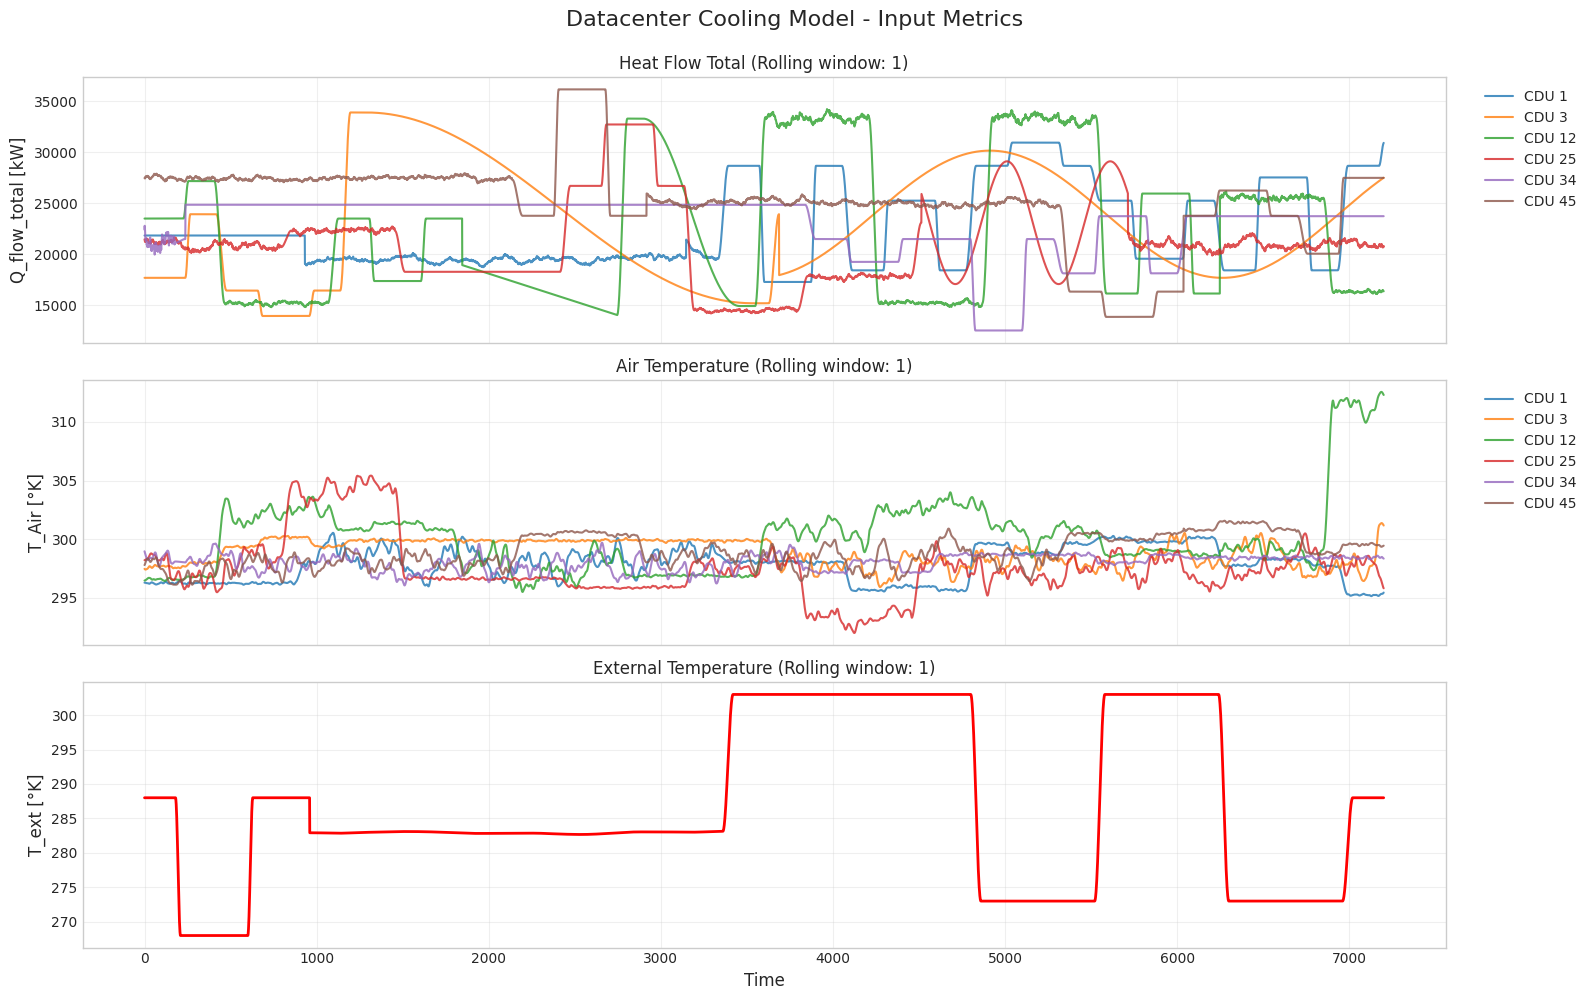

In [8]:
viz.plot_inputs(selected_cdus=[1,3,12,25,34,45,250], rolling_windows=1,time_range=[0,3600*2]);

In [9]:
raw_df = result['raw_input']
# Check that CDUs are in different phases at any timestep
phase_cols = [c for c in raw_df.columns if '_phase' in c]
print(raw_df[phase_cols].iloc[1000]) 

CDU_01_phase    steady_state
CDU_02_phase    steady_state
CDU_03_phase        settling
CDU_04_phase    steady_state
CDU_05_phase    steady_state
CDU_06_phase    steady_state
CDU_07_phase    steady_state
CDU_08_phase    steady_state
CDU_09_phase    steady_state
CDU_10_phase    steady_state
CDU_11_phase    steady_state
CDU_12_phase    steady_state
CDU_13_phase        settling
CDU_14_phase    steady_state
CDU_15_phase      transition
CDU_16_phase    steady_state
CDU_17_phase    steady_state
CDU_18_phase    steady_state
CDU_19_phase      transition
CDU_20_phase    steady_state
CDU_21_phase        settling
CDU_22_phase    steady_state
CDU_23_phase    steady_state
CDU_24_phase    steady_state
CDU_25_phase    steady_state
CDU_26_phase        settling
CDU_27_phase      transition
CDU_28_phase      transition
CDU_29_phase    steady_state
CDU_30_phase    steady_state
CDU_31_phase    steady_state
CDU_32_phase      transition
CDU_33_phase    steady_state
CDU_34_phase    steady_state
CDU_35_phase  

## Generate Output

In [12]:
from fmu2ml.simulation import FMUOutputGenerator


In [13]:
fmu_input_df = result['fmu_input']

In [14]:
input_filename = result['filename']
input_filename

'systematic_fmu_input_3hrs_lassen_45CDU_independent.parquet'

In [15]:
# 2. Generate FMU output
print("\nGenerating FMU output...")
config = ConfigManager(system_name=SYSTEM_NAME).get_config()
config_overrides = {k: v for k, v in config.items() if k != 'system_name'}

with FMUOutputGenerator(
    system_name=SYSTEM_NAME,
    stabilization_hours=3,
    stabilization_threshold=0.1,
    step_size=1,
    output_dir=f'../{SYSTEM_NAME}/data/systematic',
    **config_overrides
) as generator:
    
    actual_hours = len(fmu_input_df) / 3600
    output_filename = f"systematic_fmu_output_{actual_hours:.1f}hrs.parquet"
    
    output_df = generator.generate_from_input(
        input_data=fmu_input_df,
        output_file=f"{data_dir}/{output_filename}",
        save_stabilization=False
    )
    
    print(f"✓ Generated output: {output_filename}")
    print(f"  Shape: {output_df.shape}")


Generating FMU output...
Initializing FMU...


2026-01-28 13:02:48 - fmu2ml.simulation.fmu_output_generator - INFO - Cooling model initialized
2026-01-28 13:02:48 - fmu2ml.simulation.fmu_output_generator - INFO - FMU output generator initialized for lassen


RK-method: sdirk34hw
Local extrapolation
FSAL
Continuous extension
Initializing FMU...


2026-01-28 13:02:50 - fmu2ml.simulation.fmu_output_generator - INFO - Cooling model initialized
2026-01-28 13:02:50 - fmu2ml.simulation.fmu_output_generator - INFO - Model reset to initial state
2026-01-28 13:02:50 - fmu2ml.simulation.fmu_output_generator - INFO - Starting stabilization (max 3 hours)...


RK-method: sdirk34hw
Local extrapolation
FSAL
Continuous extension


2026-01-28 13:04:05 - fmu2ml.simulation.fmu_output_generator - INFO - Steady state reached at 2.15 hours
2026-01-28 13:04:05 - fmu2ml.simulation.fmu_output_generator - INFO - Running operational simulation for 12720 steps...
2026-01-28 13:06:50 - fmu2ml.simulation.fmu_output_generator - INFO - Progress: 9000/12720 (70.8%)
2026-01-28 13:08:01 - fmu2ml.simulation.fmu_output_generator - INFO - Output saved to: ../lassen/data/systematic/systematic_fmu_output_3.5hrs.parquet (117.4 MB)
2026-01-28 13:08:01 - fmu2ml.simulation.fmu_output_generator - INFO - Simulation complete


✓ Generated output: systematic_fmu_output_3.5hrs.parquet
  Shape: (12720, 1105)


In [16]:
import pandas as pd
output_df = pd.read_parquet(f'../{SYSTEM_NAME}/data/systematic/{output_filename}')

In [17]:
viz = StandardInputOutputVisualizer(output_df)


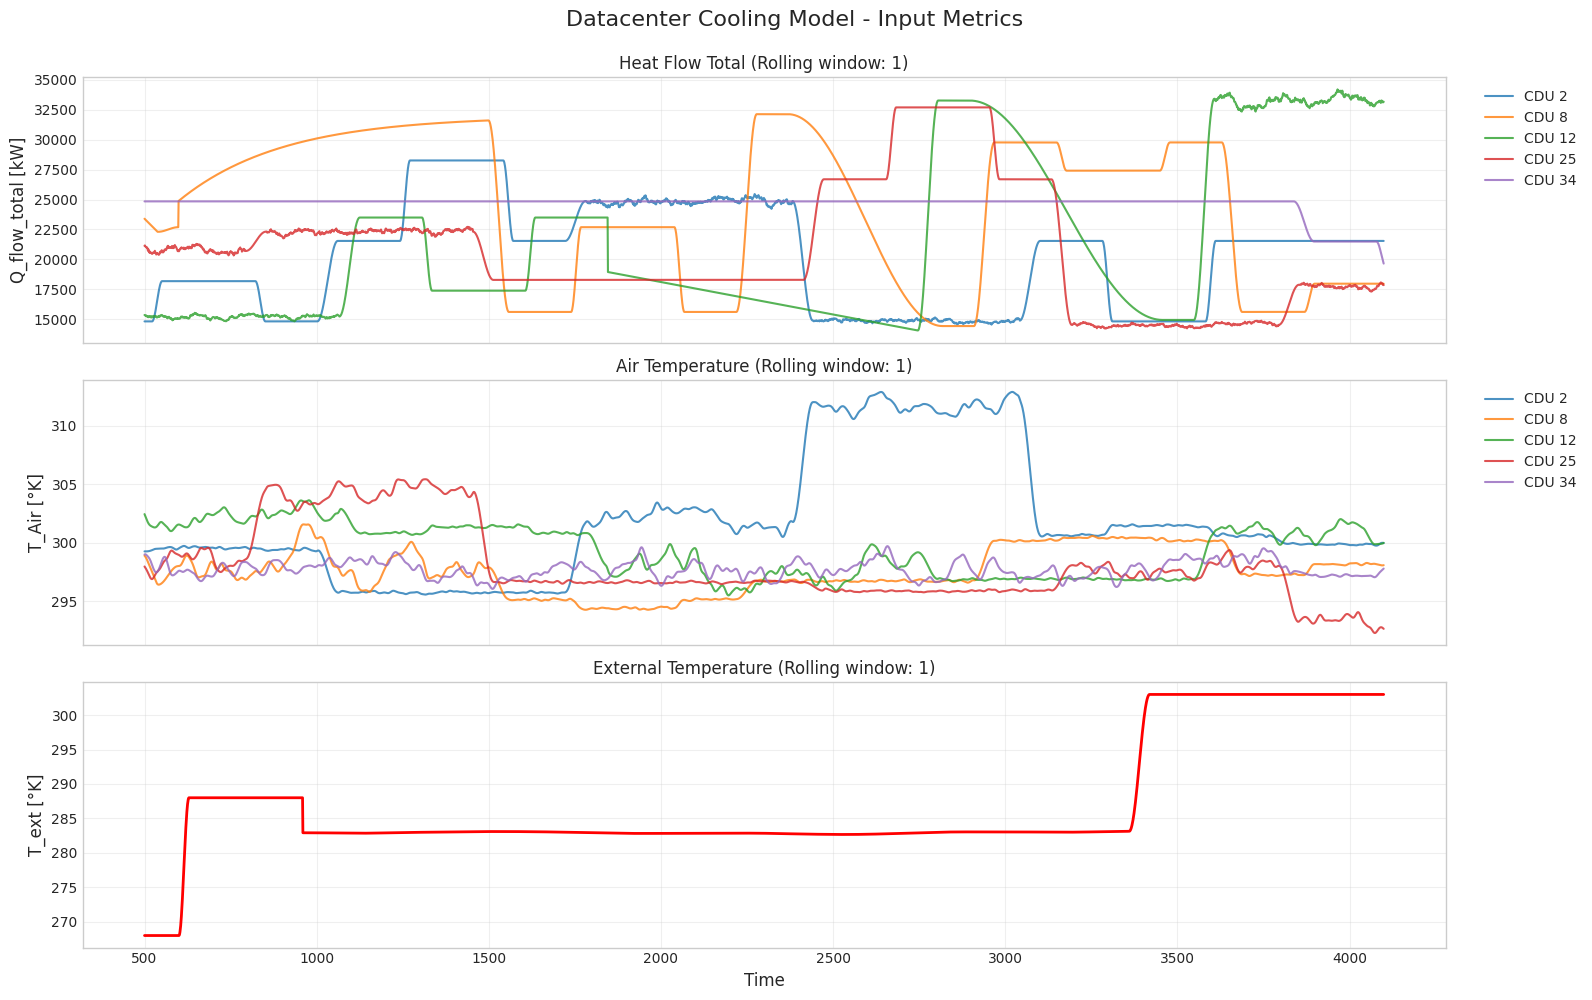

In [18]:
i=0
step=3600

viz.plot_inputs(selected_cdus=[2,8,12,25,34,45,89,135], rolling_windows=1,time_range=[step*i+500,step*(i+1)+500]);
i+=1

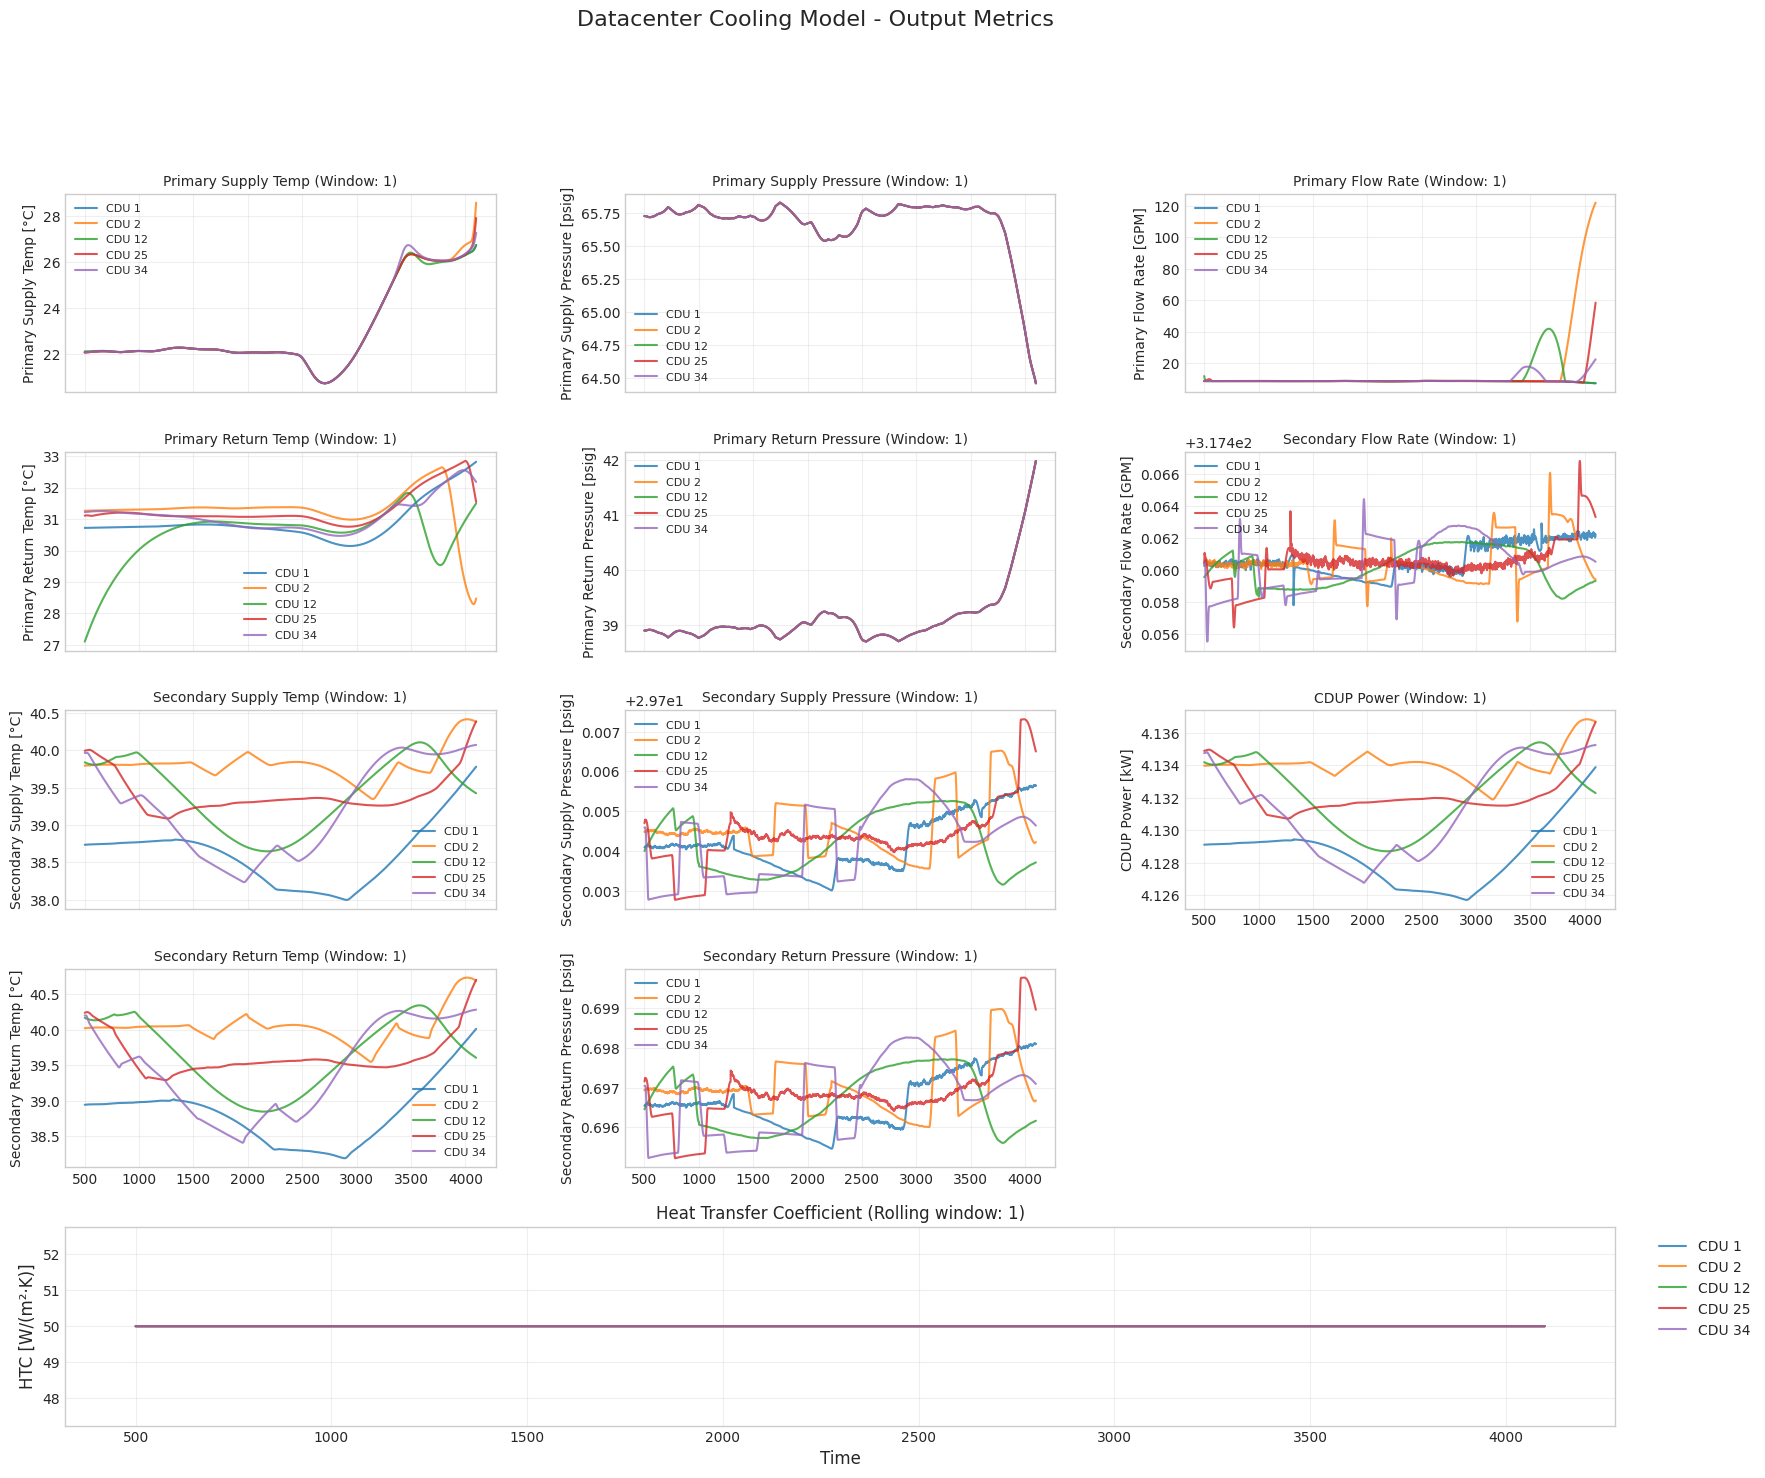

In [18]:
i=0
step=3600

viz.plot_outputs(selected_cdus=[1,2,12,25,34,45,89,135], rolling_windows=1,time_range=[step*i+500,step*(i+1)+500]);
i+=1